# Importing Libraries and Dataset

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [75]:
# Define desired headers
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# Load the file specifying that there is no existing header
df = pd.read_csv('iris-data.csv', names=column_names)

# Display the result
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [76]:
df.duplicated().sum()

3

In [77]:
df.drop_duplicates(inplace =True)
df.duplicated().sum()

0

In [78]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [79]:
df.species.value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

# BAR CHART


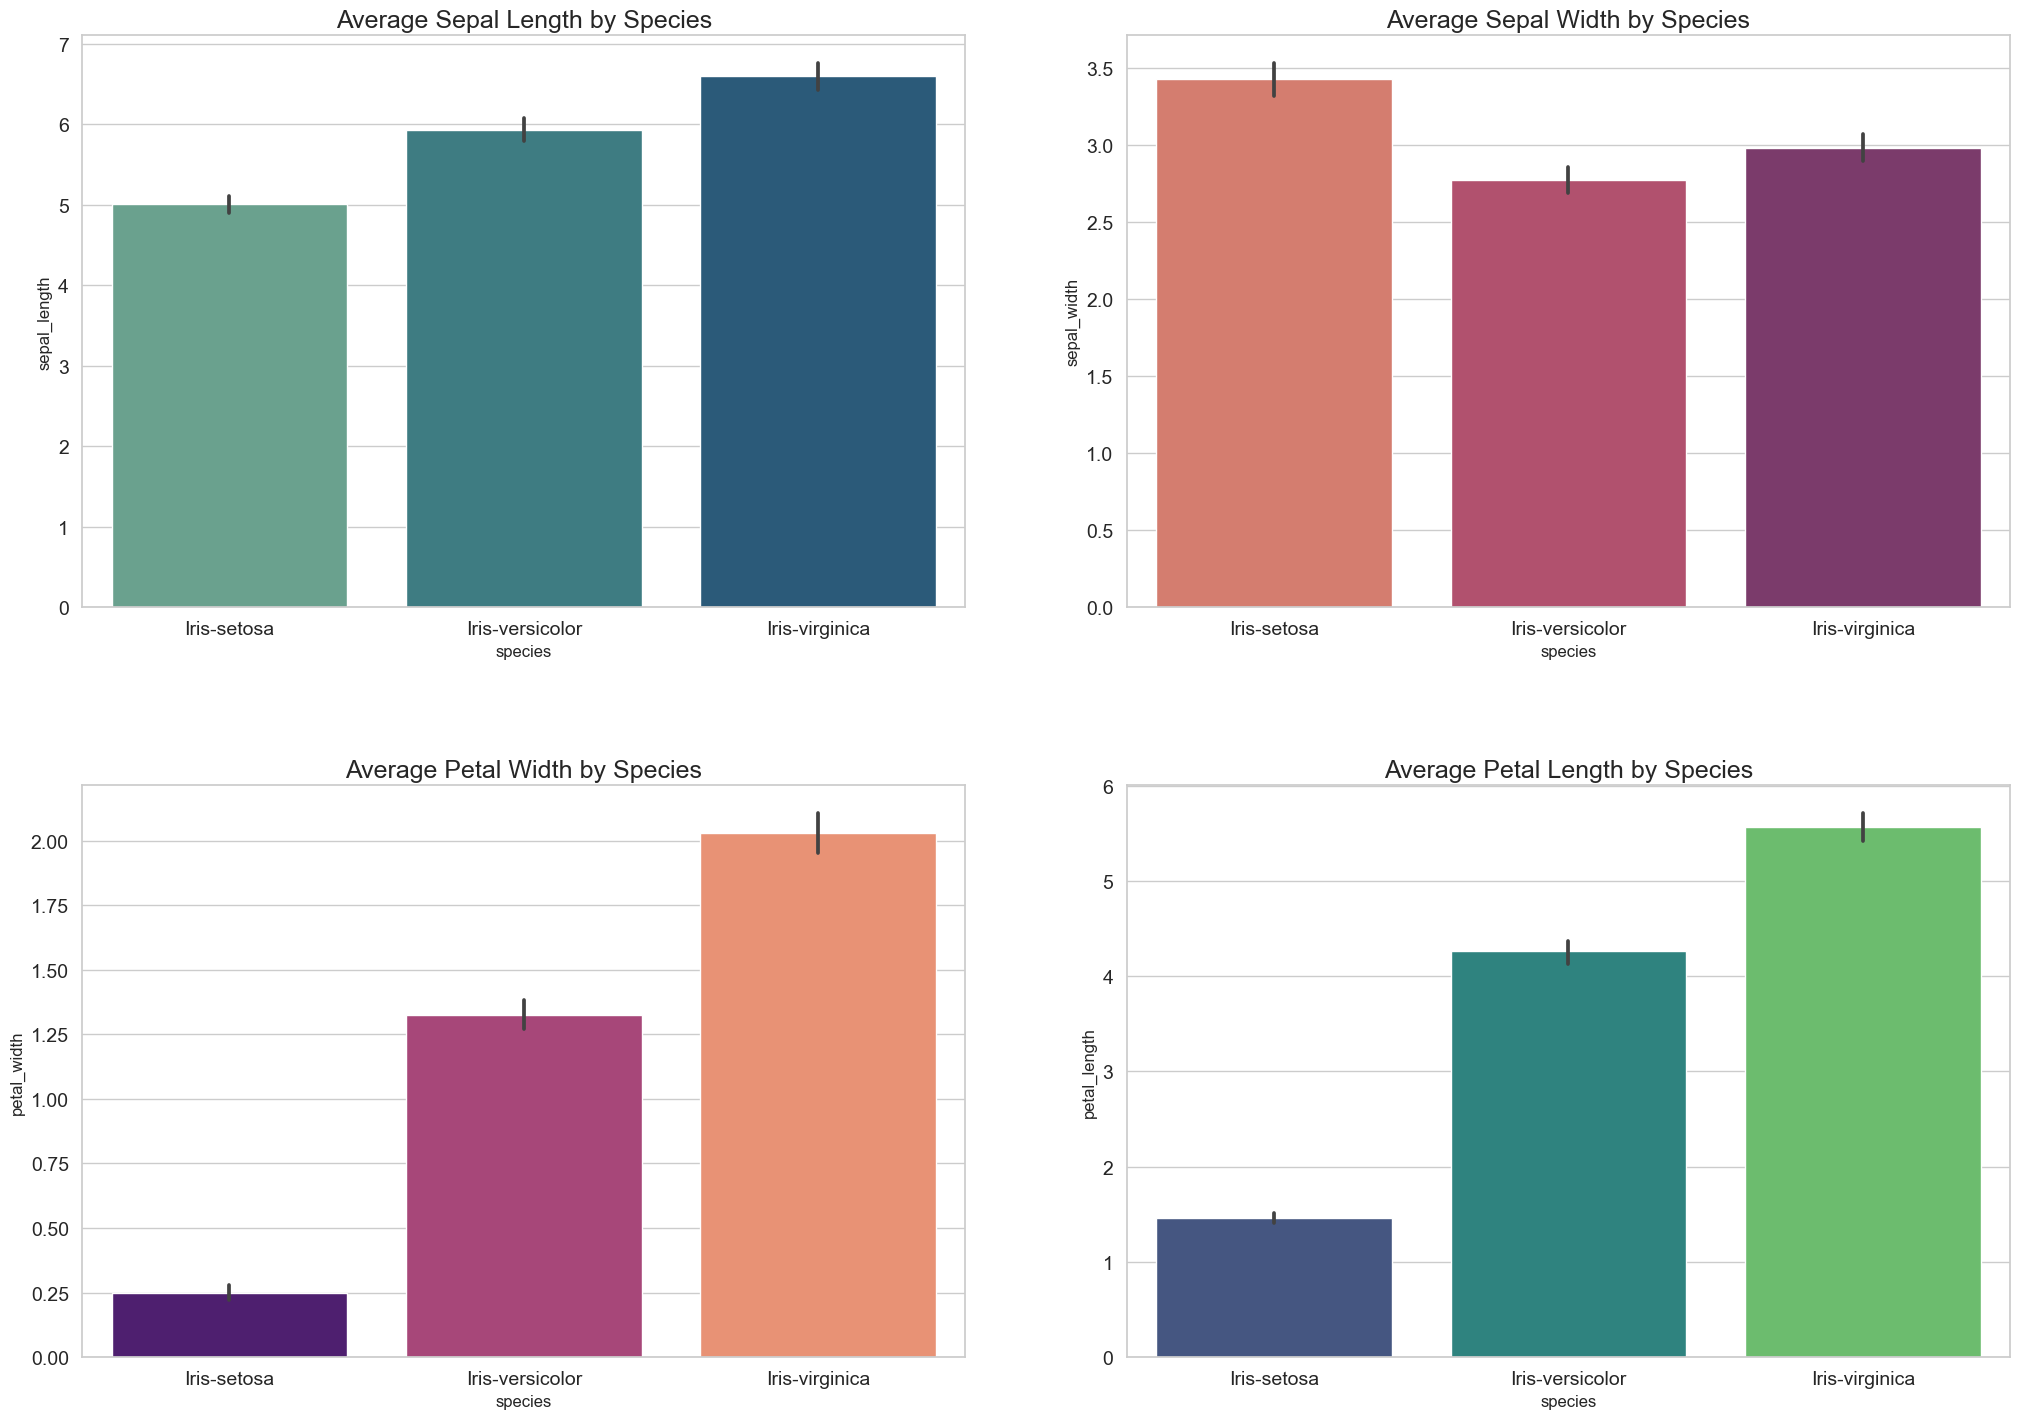

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))

# Relation 1: Sepal Length
sns.barplot(ax=axes[0][0], data=df, x='species', y='sepal_length', palette='crest')
axes[0][0].set_title('Average Sepal Length by Species',fontsize=18)
axes[0][0].tick_params(axis='both', which='major', labelsize=14) 
# Relation 2: Sepal Width (The "Outlier" Trend)
sns.barplot(ax=axes[0][1], data=df, x='species', y='sepal_width', palette='flare')
axes[0][1].set_title('Average Sepal Width by Species',fontsize=18)
axes[0][1].tick_params(axis='both', which='major', labelsize=14)
# Relation 3: Petal Width
sns.barplot(ax=axes[1][0], data=df, x='species', y='petal_width', palette='magma')
axes[1][0].set_title('Average Petal Width by Species',fontsize=18)
axes[1][0].tick_params(axis='both', which='major', labelsize=14)
# Relation 4: Petal Length
sns.barplot(ax=axes[1][1], data=df, x='species', y='petal_length', palette='viridis')
axes[1][1].set_title('Average Petal Length by Species',fontsize=18)
axes[1][1].tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout(pad=6) # Balancing the layout and uses the canvas properly
plt.show()

# HISTOGRAM

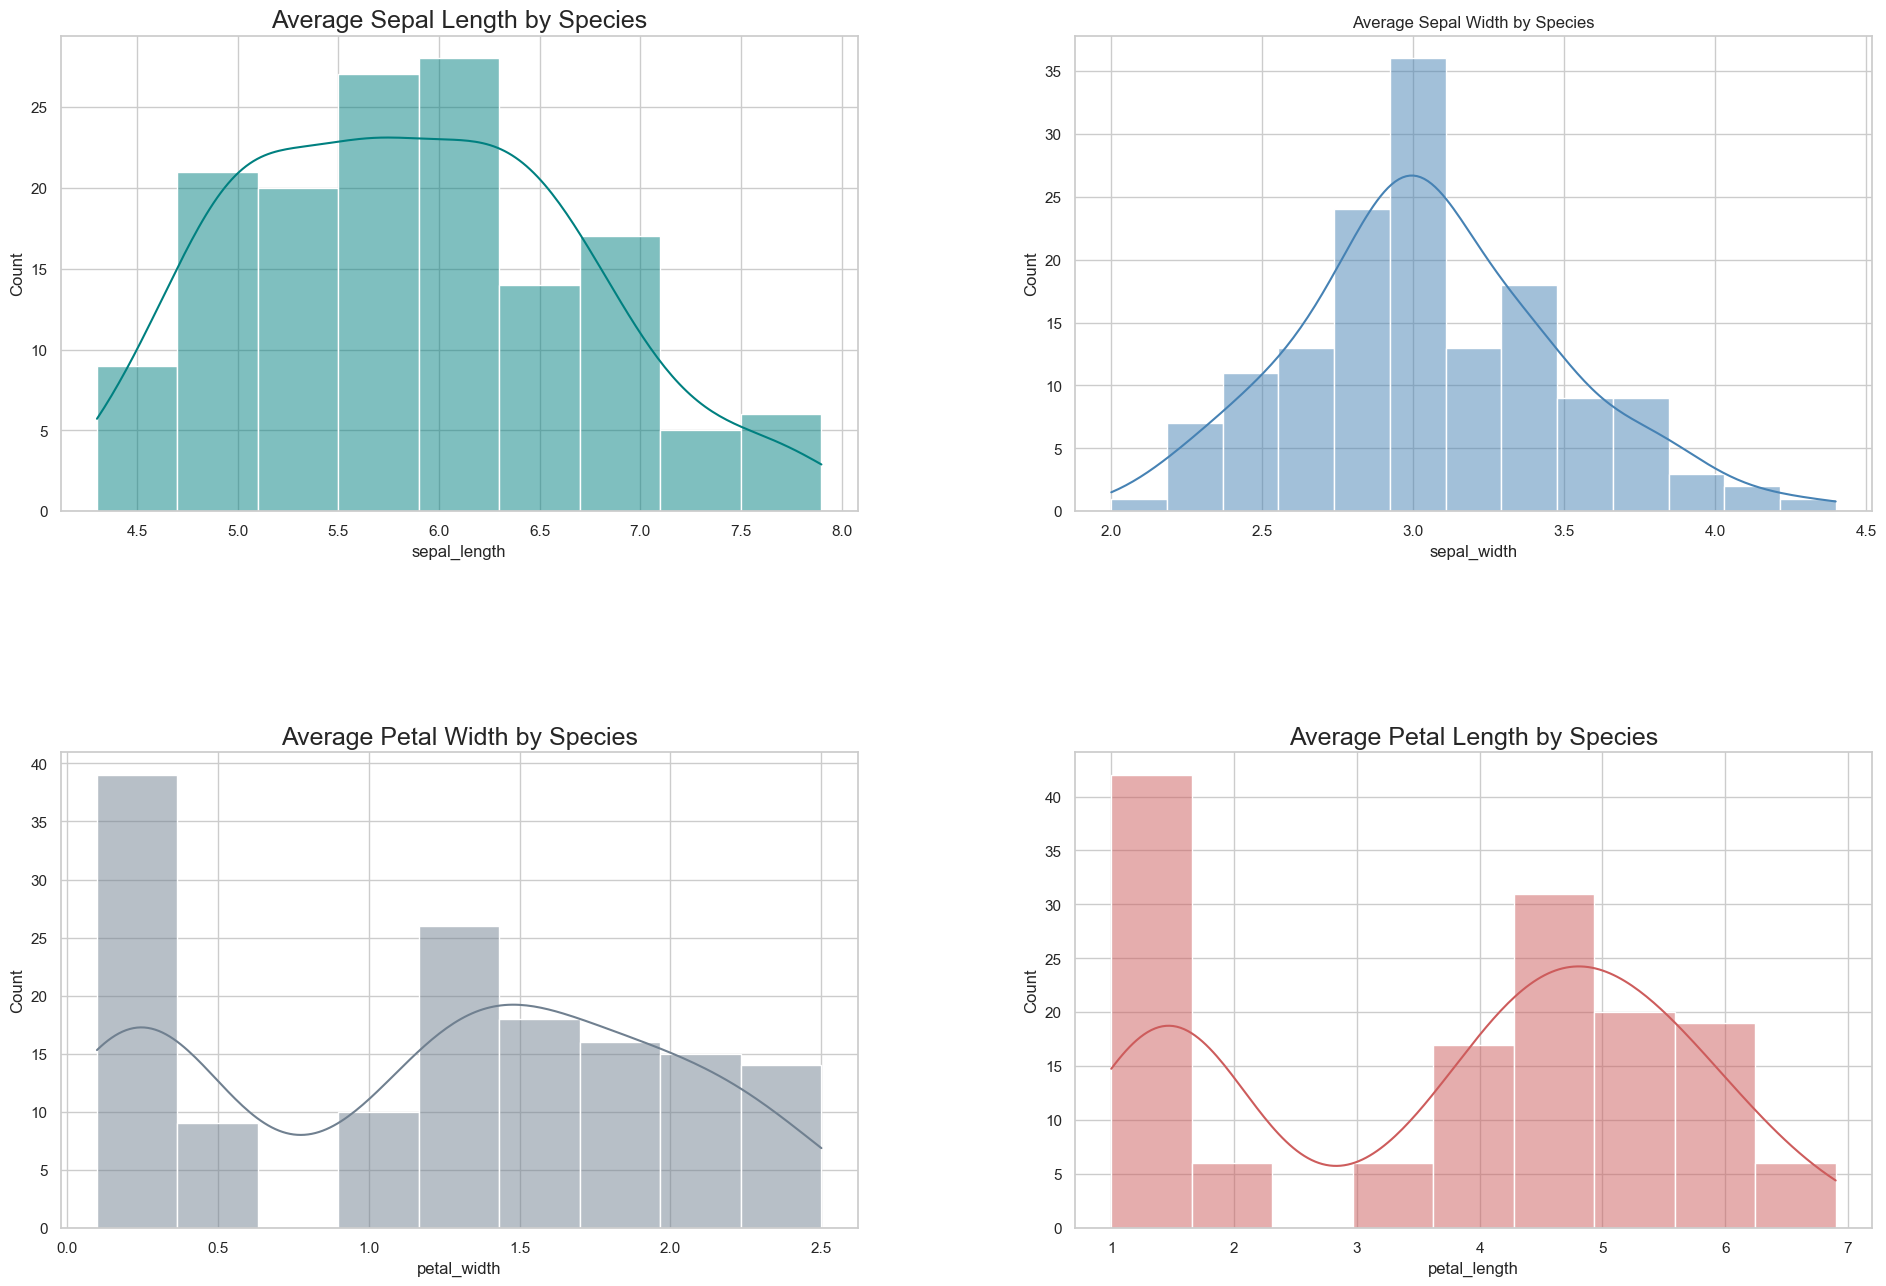

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))

# Relation 1: Sepal Length
sns.histplot(ax=axes[0][0], data=df, x='sepal_length',kde=True,color='teal')
axes[0][0].set_title('Average Sepal Length by Species',fontsize=18)

# Relation 2: Sepal Width (The "Outlier" Trend)
sns.histplot(ax=axes[0][1], data=df, x='sepal_width',kde=True,color='steelblue')
axes[0][1].set_title('Average Sepal Width by Species')

# Relation 3: Petal Width
sns.histplot(ax=axes[1][0], data=df, x='petal_width',kde=True,color='slategray')
axes[1][0].set_title('Average Petal Width by Species',fontsize=18)

# Relation 4: Petal Length
sns.histplot(ax=axes[1][1], data=df, x='petal_length',kde=True,color='indianred')
axes[1][1].set_title('Average Petal Length by Species',fontsize=18)

plt.tight_layout(pad=10) # Balancing the layout and uses the canvas properly
plt.show()



# SCATTER PLOT

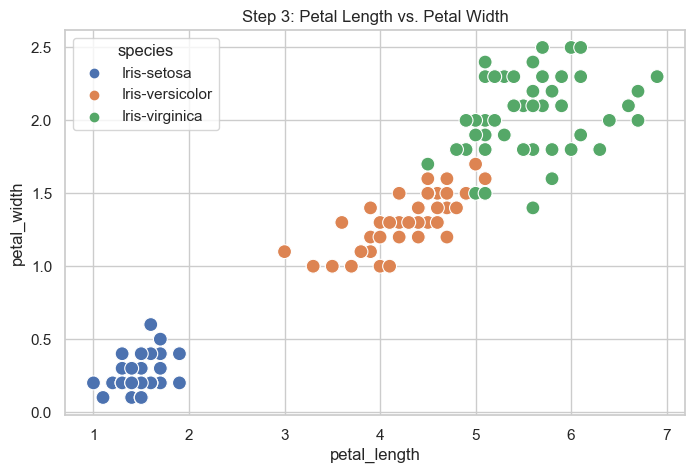

In [66]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=100)
plt.title('Step 3: Petal Length vs. Petal Width')
plt.show()

D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


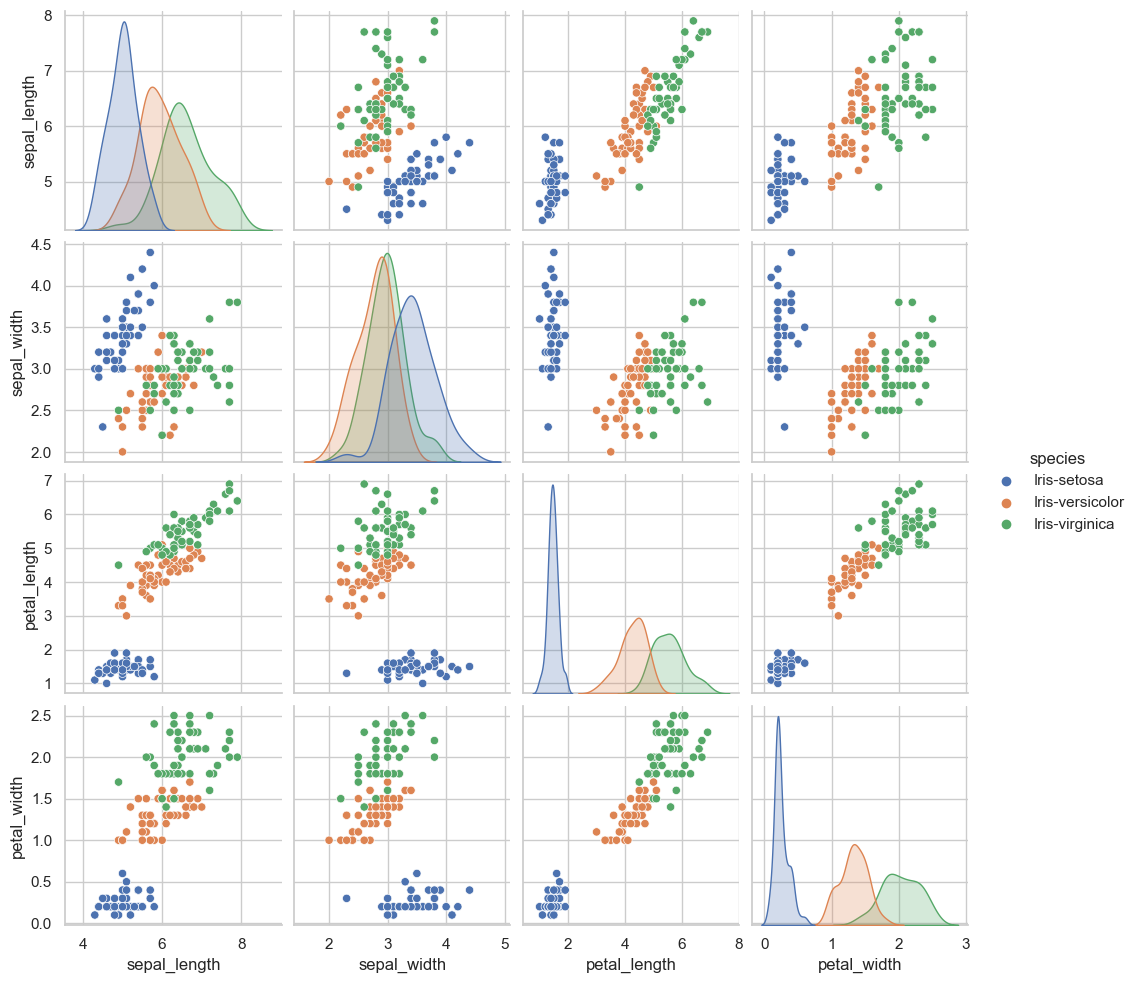

In [134]:
sns.pairplot(df, hue='species')

# Compare features

Before diving into feature comparisons, the dataset was properly prepared by removing three duplicate rows and verifying that no null values exist. The target classes are well-balanced, with 50 instances of Iris-versicolor, 49 of Iris-virginica, and 48 of Iris-setosa.



The petal measurements (petal_length and petal_width) are the most significant features for species classification. As seen in the histograms and pairplot, the distributions of petal length and width for Iris-setosa are completely isolated from the other two species.


There is a near-perfect positive linear correlation between petal length and petal width across all species.

Interestingly, Iris-setosa, which has the smallest dimensions in three of the four categories, actually possesses the widest sepals on average. This makes sepal_width a crucial feature for identifying Setosa despite its otherwise small stature.

Iris-virginica tends to have the longest sepals, followed by Versicolor and then Setosa. However, the scatter plots show significant overlap between Virginica and Versicolor in sepal length, making it a weaker primary classifier than petal length.

A simple rules-based approach (if petal_length < 2.5cm, then Setosa) would achieve 100% accuracy for one class. Differentiating between the remaining two would best be handled by a Support Vector Machine (SVM) or Random Forest to manage the slight overlap in sepal dimensions.